In [117]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K 
from keras.optimizers import Adam
from keras.utils import to_categorical
from tensorflow.compat.v1.logging import INFO, set_verbosity
from sklearn.model_selection import train_test_split

# Una pequeña verificación para asegurarte de que Python lo detecta:
print("Versión de TensorFlow:", tf.__version__)
print("Versión de Keras integrada:", keras.__version__)

Versión de TensorFlow: 2.21.0
Versión de Keras integrada: 3.14.1


In [118]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nibabel as nib
import glob
from sklearn.model_selection import train_test_split
import cv2
import os
set_verbosity(INFO)

## Exploracion dataset 

In [119]:
DATA_DIR = r"C:\Users\marin\OneDrive\Escritorio\DATA ESPECIALIZACION\PROYECTO FINAL\datos\BraTS-PEDs-v1\Training"


def load_case(image_files_list, label_file):
    # load the image and label file, get the image content and return a numpy array for each
    
    t1   = nib.load(image_files_list[0]).get_fdata()
    t1ce = nib.load(image_files_list[1]).get_fdata()
    t2   = nib.load(image_files_list[2]).get_fdata()
    flair = nib.load(image_files_list[3]).get_fdata()
    
    # 2. Las apilamos en el eje final para crear los canales (X, Y, Z, 4)
    image = np.stack([t1, t1ce, t2, flair], axis=-1)
    
    # 3. Cargamos la etiqueta de segmentación normalmente
    label = nib.load(label_file).get_fdata().astype(np.int16)
    
    return image, label

In [120]:
def plot_image_grid(image):
    data_all = []

    data_all.append(image)

    fig, ax = plt.subplots(3, 6, figsize=[16, 9])

    # coronal plane
    coronal = np.transpose(data_all, [1, 3, 2, 4, 0])
    coronal = np.rot90(coronal, 1)

    # transversal plane
    transversal = np.transpose(data_all, [2, 1, 3, 4, 0])
    transversal = np.rot90(transversal, 2)

    # sagittal plane
    sagittal = np.transpose(data_all, [2, 3, 1, 4, 0])
    sagittal = np.rot90(sagittal, 1)

    for i in range(6):
        n = np.random.randint(coronal.shape[2])
        ax[0][i].imshow(np.squeeze(coronal[:, :, n, :]))
        ax[0][i].set_xticks([])
        ax[0][i].set_yticks([])
        if i == 0:
            ax[0][i].set_ylabel('Coronal', fontsize=15)

    for i in range(6):
        n = np.random.randint(transversal.shape[2])
        ax[1][i].imshow(np.squeeze(transversal[:, :, n, :]))
        ax[1][i].set_xticks([])
        ax[1][i].set_yticks([])
        if i == 0:
            ax[1][i].set_ylabel('Transversal', fontsize=15)

    for i in range(6):
        n = np.random.randint(sagittal.shape[2])
        ax[2][i].imshow(np.squeeze(sagittal[:, :, n, :]))
        ax[2][i].set_xticks([])
        ax[2][i].set_yticks([])
        if i == 0:
            ax[2][i].set_ylabel('Sagittal', fontsize=15)

    fig.subplots_adjust(wspace=0, hspace=0)



In [121]:
modalidades_p1 = [
    DATA_DIR + r"/BraTS-PED-00001-000\BraTS-PED-00001-000-seg.nii.gz",   # T1 Nativo
    DATA_DIR + r"/BraTS-PED-00001-000\BraTS-PED-00001-000-t1c.nii.gz",   # T1 con Contraste
    DATA_DIR + r"/BraTS-PED-00001-000\BraTS-PED-00001-000-t2w.nii.gz",   # T2
    DATA_DIR + r"/BraTS-PED-00001-000\BraTS-PED-00001-000-t2f.nii.gz"  # FLAIR
]

# 2. Le pasamos la lista de imágenes y el archivo -seg (el label) a la función de arriba
image, label = load_case(modalidades_p1, DATA_DIR + r"/BraTS-PED-00001-000/BraTS-PED-00001-000-seg.nii.gz")


In [122]:
#image = get_labeled_image(image, label)

#plot_image_grid(image)

In [123]:
image.shape

(240, 240, 155, 4)

In [124]:
#miramos la forma de la imagen : 
height, width, depth, channels = image.shape
print(f"la imagen tiene las siguientes dimensiones: alto: {height}, ancho: {width}, profundidad: {depth} capas, canales:{channels} (una imagen por cada canal)")

la imagen tiene las siguientes dimensiones: alto: 240, ancho: 240, profundidad: 155 capas, canales:4 (una imagen por cada canal)


In [125]:
#miramos la forma de la imagen correspondiente al label 
height, width, depth= label.shape 

print(f"la imagen tiene las siguientes dimensiones: alto: {height}, ancho: {width}, profundidad: {depth} capas")


la imagen tiene las siguientes dimensiones: alto: 240, ancho: 240, profundidad: 155 capas


In [126]:
image_lenght= image.shape[0]
image_lenght

240

In [127]:
#contenido del archivo del label 
print(f"valores unicos del archivo segmentacion de tumor : {np.unique(label)}")

print("""
Corresponding to the following label categories: 
0: for normal 
1: for Enhancing Tumor (ET): Areas showing contrast enhancement on T1CE relative to T1.
2: for Non-Enhancing Tumor (NET): Abnormal signal intensity within the tumor not classified as ET or cystic, typically visible across T1, T2, or FLAIR without enhancement.
3: for Cystic Component (CC): Fluid-filled tumor regions, hyperintense on T2 and hypointense on T1CE, with intensity comparable to cerebrospinal fluid.
4: for Peritumoral Edema (ED): Hyperintense signal on FLAIR scans, appearing as finger-like spread that preserves underlying brain structure.
""")

valores unicos del archivo segmentacion de tumor : [0 1 2 3 4]

Corresponding to the following label categories: 
0: for normal 
1: for Enhancing Tumor (ET): Areas showing contrast enhancement on T1CE relative to T1.
2: for Non-Enhancing Tumor (NET): Abnormal signal intensity within the tumor not classified as ET or cystic, typically visible across T1, T2, or FLAIR without enhancement.
3: for Cystic Component (CC): Fluid-filled tumor regions, hyperintense on T2 and hypointense on T1CE, with intensity comparable to cerebrospinal fluid.
4: for Peritumoral Edema (ED): Hyperintense signal on FLAIR scans, appearing as finger-like spread that preserves underlying brain structure.



## Procesamiento previo de los datos : elaboracion de parches (subvolumenes)


In [128]:
def get_sub_volume(image, label, 
                   orig_x = 240, orig_y = 240, orig_z = 155, 
                   output_x = 160, output_y = 160, output_z = 16,
                   num_classes = 5, max_tries = 1000, 
                   background_threshold=0.95):
    """
    Extract random sub-volume from original images.

    Args:
        image (np.array): original image, 
            of shape (orig_x, orig_y, orig_z, num_channels)
        label (np.array): original label. 
            labels coded using discrete values rather than
            a separate dimension, 
            so this is of shape (orig_x, orig_y, orig_z)
        orig_x (int): x_dim of input image
        orig_y (int): y_dim of input image
        orig_z (int): z_dim of input image
        output_x (int): desired x_dim of output
        output_y (int): desired y_dim of output
        output_z (int): desired z_dim of output
        num_classes (int): number of class labels
        max_tries (int): maximum trials to do when sampling
        background_threshold (float): limit on the fraction 
            of the sample which can be the background

    returns:
        X (np.array): sample of original image of dimension 
            (num_channels, output_x, output_y, output_z)
        y (np.array): labels which correspond to X, of dimension 
            (num_classes, output_x, output_y, output_z)
    """
    # Initialize features and labels with `None`
    X = None
    y = None

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    
    tries = 0
    
    while tries < max_tries:
        # randomly sample sub-volume by sampling the corner voxel
        # hint: make sure to leave enough room for the output dimensions!
        # do not remove/delete the '0's
        start_x = np.random.randint(0 , orig_x - output_x + 1)
        start_y = np.random.randint(0 , orig_y - output_y + 1)
        start_z = np.random.randint(0 , orig_z - output_z + 1)
        
        # extract relevant area of label
        y = label[start_x: start_x + output_x,
                  start_y: start_y + output_y,
                  start_z: start_z + output_z]
        
        # One-hot encode the categories.
        # This adds a 4th dimension, 'num_classes'
        # (output_x, output_y, output_z, num_classes)
        y = keras.utils.to_categorical(y, num_classes = num_classes)

        # compute the background ratio (this has been implemented for you)
        bgrd_ratio = np.sum(y[:, :, :, 0])/(output_x * output_y * output_z)

        # increment tries counter
        tries += 1

        # if background ratio is below the desired threshold,
        # use that sub-volume.
        # otherwise continue the loop and try another random sub-volume
        if bgrd_ratio < background_threshold:

            # make copy of the sub-volume
            X = np.copy(image[start_x: start_x + output_x,
                              start_y: start_y + output_y,
                              start_z: start_z + output_z, :])
            
            # change dimension of X
            # from (x_dim, y_dim, z_dim, num_channels)
            # to (num_channels, x_dim, y_dim, z_dim)
            X = np.moveaxis(X,3,0)

            # change dimension of y
            # from (x_dim, y_dim, z_dim, num_classes)
            # to (num_classes, x_dim, y_dim, z_dim)
            y = np.moveaxis(y,3,0)

            ### END CODE HERE ###
            
            # take a subset of y that excludes the background class
            # in the 'num_classes' dimension
            y = y[1:, :, :, :]
    
            return X, y

    # if we've tried max_tries number of samples
    # Give up in order to avoid looping forever.
    print(f"Tried {tries} times to find a sub-volume. Giving up...")

In [129]:
def visualize_patch(X, y):
    fig, ax = plt.subplots(1, 2, figsize=[10, 5], squeeze=False)

    ax[0][0].imshow(X[:, :, 0], cmap='Greys_r')
    ax[0][0].set_yticks([])
    ax[0][0].set_xticks([])
    ax[0][1].imshow(y[:, :, 0], cmap='Greys_r')
    ax[0][1].set_xticks([])
    ax[0][1].set_yticks([])

    fig.subplots_adjust(wspace=0, hspace=0)

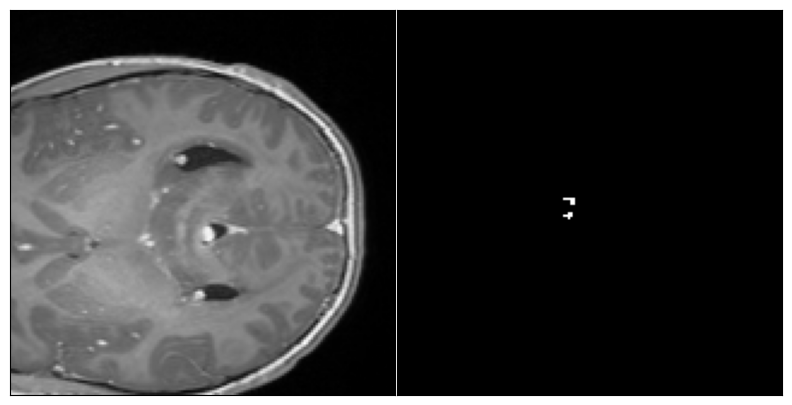

In [130]:
image, label = load_case (modalidades_p1, DATA_DIR + r"/BraTS-PED-00001-000/BraTS-PED-00001-000-seg.nii.gz")
X, y = get_sub_volume(image, label)
# enhancing tumor is channel 2 in the class label
# you can change indexer for y to look at different classes
visualize_patch(X[1, :, :, :], y[2])

### Estandarización 

In [145]:
def standardize(image):
    """
    Standardize mean and standard deviation 
        of each channel and z_dimension.

    Args:
        image (np.array): input image, 
            shape (num_channels, dim_x, dim_y, dim_z)

    Returns:
        standardized_image (np.array): standardized version of input image
    """
    
    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    
    # initialize to array of zeros, with same shape as the image
    standardized_image = np.zeros(image.shape)

    # iterate over channels
    for c in range(image.shape[0]):
        # iterate over the `z` dimension
        for z in range(image.shape[3]):
            # get a slice of the image 
            # at channel c and z-th dimension `z`
            image_slice = image[c,:,:,z]

            # subtract the mean from image_slice
            centered = image_slice - np.mean(image_slice)
            
            # divide by the standard deviation (only if it is different from zero)
            if np.std(centered) != 0:
                centered_scaled = centered / np.std(centered)

                # update  the slice of standardized image
                # with the scaled centered and scaled image
            standardized_image[c, :, :, z] = centered_scaled

    ### END CODE HERE ###

    return standardized_image

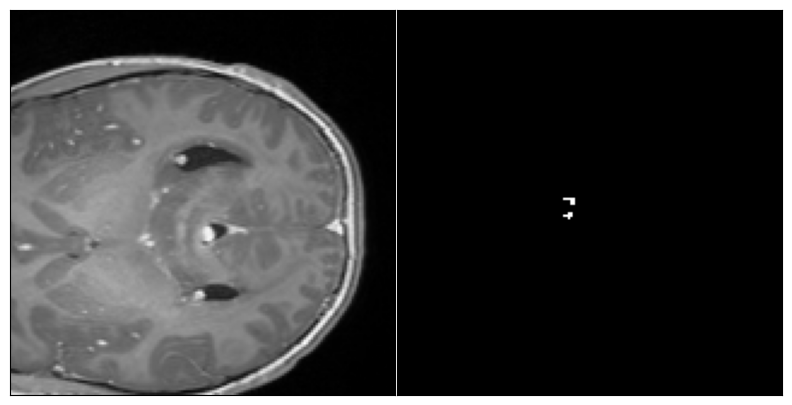

In [144]:
X_norm = standardize(X)
visualize_patch(X_norm[1, :, :, :], y[2])

## DICE COEFFICIENT 

In [133]:
def single_class_dice_coefficient(y_true, y_pred, axis=(0, 1, 2), 
                                  epsilon=0.00001):
    """
    Compute dice coefficient for single class.

    Args:
        y_true (Tensorflow tensor): tensor of ground truth values for single class.
                                    shape: (x_dim, y_dim, z_dim)
        y_pred (Tensorflow tensor): tensor of predictions for single class.
                                    shape: (x_dim, y_dim, z_dim)
        axis (tuple): spatial axes to sum over when computing numerator and
                      denominator of dice coefficient.
                      Hint: pass this as the 'axis' argument to the K.sum function.
        epsilon (float): small constant added to numerator and denominator to
                        avoid divide by 0 errors.
    Returns:
        dice_coefficient (float): computed value of dice coefficient.     
    """

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    
    dice_numerator = 2 * K.sum(y_true * y_pred, axis = axis) + epsilon
    dice_denominator = K.sum(y_true,axis= axis) + K.sum(y_pred, axis= axis) + epsilon
    dice_coefficient = dice_numerator / dice_denominator
    
    ### END CODE HERE ###

    return dice_coefficient

### Dice coefficient para las 4 clases (Enhancing Tumor, Non-Enhancing Tumor (NET), Cystic Component (CC), Peritumoral Edema (ED))

In [134]:
def dice_coefficient(y_true, y_pred, axis=(1, 2, 3), 
                     epsilon=0.00001):
    """
    Compute mean dice coefficient over all abnormality classes.

    Args:
        y_true (Tensorflow tensor): tensor of ground truth values for all classes.
                                    shape: (num_classes, x_dim, y_dim, z_dim)
        y_pred (Tensorflow tensor): tensor of predictions for all classes.
                                    shape: (num_classes, x_dim, y_dim, z_dim)
        axis (tuple): spatial axes to sum over when computing numerator and
                      denominator of dice coefficient.
                      Hint: pass this as the 'axis' argument to the K.sum function.
        epsilon (float): small constant add to numerator and denominator to
                        avoid divide by 0 errors.
    Returns:
        dice_coefficient (float): computed value of dice coefficient.     
    """

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    
    dice_numerator = 2 * K.sum(y_true * y_pred , axis = axis) + epsilon
    dice_denominator = K.sum(y_true, axis = axis ) + K.sum(y_pred, axis = axis) + epsilon
    dice_coefficient = K.mean(dice_numerator/dice_denominator)
    
    ### END CODE HERE ###

    return dice_coefficient



### Soft dice coefficient 
explicacion: 


In [135]:
def soft_dice_loss(y_true, y_pred, axis=(1, 2, 3), epsilon=0.00001):
    """ Compute mean soft dice loss over all abnormality classes.

    Args:
        y_true (Tensorflow tensor): tensor of ground truth values for all classes.
                                    shape: (num_classes, x_dim, y_dim, z_dim)
        y_pred (Tensorflow tensor): tensor of soft predictions for all classes.
                                    shape: (num_classes, x_dim, y_dim, z_dim)
        axis (tuple): spatial axes to sum over when computing numerator and
                      denominator in formula for dice loss.
                      Hint: pass this as the 'axis' argument to the K.sum function.
        epsilon (float): small constant added to numerator and denominator to
                         avoid divide by 0 errors.
    Returns:
        dice_loss (float): computed value of dice loss.     
    """

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###

    dice_numerator = 2 * K.sum(y_true * y_pred, axis=axis) + epsilon
    dice_denominator = K.sum(y_true ** 2, axis=axis) + K.sum(y_pred ** 2, axis=axis) + epsilon
    dice_loss = 1 - K.mean(dice_numerator / dice_denominator)

    ### END CODE HERE ###

    return dice_loss

## Volume Data Generator 

In [146]:
class VolumeDataGenerator(keras.utils.Sequence):
    """
    Carga los volúmenes completos y extrae parches 3D en tiempo real.
    """
    def __init__(self, sample_list, base_dir, batch_size=1, shuffle=True,
                 dim=(160, 160, 16), num_channels=4, num_classes=4, verbose=1):
        self.sample_list = sample_list
        self.base_dir = base_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.dim = dim
        self.num_channels = num_channels
        self.num_classes = num_classes  
        self.verbose = verbose
        self.on_epoch_end()

    def on_epoch_end(self):
        """Actualiza y mezcla los índices al final de cada época"""
        self.indexes = np.arange(len(self.sample_list))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __len__(self):
        """Denota el número total de lotes (batches) por época"""
        return int(np.floor(len(self.sample_list) / self.batch_size))

    def __data_generation(self, list_IDs_temp):
        """Carga las imágenes completas y extrae los parches tridimensionales"""
        # Inicializamos las matrices del lote con ceros (formato channels_first)
        X = np.zeros((self.batch_size, self.num_channels, *self.dim), dtype=np.float64)
        y = np.zeros((self.batch_size, self.num_classes, *self.dim), dtype=np.float64)

        for i, ID in enumerate(list_IDs_temp):
            if self.verbose == 1:
                print(f"Generando parches 3D en tiempo real para: {ID}")
            
            # Construimos la ruta base hacia los archivos del paciente
            # C:\...\Training\BraTS-PED-00002-000\BraTS-PED-00002-000
            patient_folder_path = os.path.join(self.base_dir, ID, ID)
            
            # Definimos las rutas exactas de tus 4 modalidades NIfTI
            image_files_list = [
                patient_folder_path + "-t1.nii.gz",
                patient_folder_path + "-t1c.nii.gz",
                patient_folder_path + "-t2f.nii.gz",  # Secuencia FLAIR
                patient_folder_path + "-t2w.nii.gz"
            ]
            label_file = patient_folder_path + "-seg.nii.gz"
            
            # 1. Carga de los volúmenes completos usando tu función original
            img_completa, mask_completa = load_case(image_files_list, label_file)
            
            # 2. Extracción del parche usando tu función get_sub_volume
            # Le pasamos num_classes=5 para el to_categorical antes de que elimine el fondo
            parche_x, parche_y = get_sub_volume(
                img_completa, mask_completa,
                orig_x=240, orig_y=240, orig_z=155,
                output_x=self.dim[0], output_y=self.dim[1], output_z=self.dim[2],
                num_classes=5  
            )
            
            # 3. Normalizacion de los parches de las imagenes 
            parche_x_normalizado= standardize(parche_x_normalizado)

            # 4. Almacenamos el parche procesado dentro del lote actual
            X[i] = parche_x_normalizado
            y[i] = parche_y

        return X, y

    def __getitem__(self, index):
        """Genera un lote completo de datos cuando Keras lo solicita"""
        indexes = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]
        sample_list_temp = [self.sample_list[k] for k in indexes]
        X, y = self.__data_generation(sample_list_temp)
        return X, y

## Segmentacion Data en Train - Validation - Test 

In [143]:
import os
from sklearn.model_selection import train_test_split

# 1. Defines la ruta a tu carpeta
ruta_train = r"C:\Users\marin\OneDrive\Escritorio\DATA ESPECIALIZACION\PROYECTO FINAL\datos\BraTS-PEDs-v1\Training"


# 2. Obtienes las listas de pacientes de cada directorio
pacientes_completos = sorted(os.listdir(ruta_train))  # los 257 pacientes 


# 3. Primer corte: Reservamos el 20% del total para (Validación + Test)
# El 80% restante se guarda directamente en 'pacientes_train' (~205 niños)
pacientes_train, pacientes_temporales = train_test_split(
    pacientes_completos, 
    test_size=0.20,          # 20% para el subconjunto de validación/test
    random_state=42          # Para que no cambie al volver a ejecutar
)
#4. Segundo corte: Ese 20% temporal lo dividimos a la mitad (50/50)
# Así obtenemos un 10% puro para Validación (~26 niños) y un 10% puro para Test (~26 niños)
pacientes_val, pacientes_test = train_test_split(
    pacientes_temporales, 
    test_size= 0.50, 
    random_state=42
)
# Control de inventario en tu consola
print(f"Pipeline configurado correctamente:")
print(f" └── Train: {len(pacientes_train)} pacientes (Ruta: {ruta_train})")
print(f" └── Validation: {len(pacientes_val)} pacientes (Ruta: {ruta_train})")
print(f" └── Test Final: {len(pacientes_test)} pacientes (Ruta: {ruta_train})")
print(f"\nTotal pacientes utilizados con etiquetas: {len(pacientes_train) + len(pacientes_val) + len(pacientes_test)}")

Pipeline configurado correctamente:
 └── Train: 205 pacientes (Ruta: C:\Users\marin\OneDrive\Escritorio\DATA ESPECIALIZACION\PROYECTO FINAL\datos\BraTS-PEDs-v1\Training)
 └── Validation: 26 pacientes (Ruta: C:\Users\marin\OneDrive\Escritorio\DATA ESPECIALIZACION\PROYECTO FINAL\datos\BraTS-PEDs-v1\Training)
 └── Test Final: 26 pacientes (Ruta: C:\Users\marin\OneDrive\Escritorio\DATA ESPECIALIZACION\PROYECTO FINAL\datos\BraTS-PEDs-v1\Training)

Total pacientes utilizados con etiquetas: 257


In [138]:
# Generador de entrenamiento: apunta a la carpeta Training
#train_generator = VolumeDataGenerator(pacientes_train, ruta_train, ...)

# Generador de validación: apunta a la carpeta Validation, pero solo usa su mitad
#val_generator = VolumeDataGenerator(pacientes_val, ruta_train, ...)

# Generador de test: apunta a la carpeta Validation, usando la otra mitad guardada
#test_generator = VolumeDataGenerator(pacientes_test, ruta_train, ...)

## Modelo 

In [139]:
def create_convolution_block(input_layer, n_filters, batch_normalization=False,
                             kernel=(3, 3, 3), activation=None,
                             padding='same', strides=(1, 1, 1),
                             instance_normalization=False):
    """
    :param strides:
    :param input_layer:
    :param n_filters:
    :param batch_normalization:
    :param kernel:
    :param activation: Keras activation layer to use. (default is 'relu')
    :param padding:
    :return:
    """
    layer = Conv3D(n_filters, kernel, padding=padding, strides=strides)(
        input_layer)
    if activation is None:
        return Activation('relu')(layer)
    else:
        return activation()(layer)


def get_up_convolution(n_filters, pool_size, kernel_size=(2, 2, 2),
                       strides=(2, 2, 2),
                       deconvolution=False):
    if deconvolution:
        return Deconvolution3D(filters=n_filters, kernel_size=kernel_size,
                               strides=strides)
    else:
        return UpSampling3D(size=pool_size)


def unet_model_3d(loss_function, input_shape=(4, 160, 160, 16),
                  pool_size=(2, 2, 2), n_labels=4,
                  initial_learning_rate=0.00001,
                  deconvolution=False, depth=4, n_base_filters=32,
                  include_label_wise_dice_coefficients=False, metrics=[],
                  batch_normalization=False, activation_name="sigmoid"):
    """
    Builds the 3D UNet Keras model.f
    :param metrics: List metrics to be calculated during model training (default is dice coefficient).
    :param include_label_wise_dice_coefficients: If True and n_labels is greater than 1, model will report the dice
    coefficient for each label as metric.
    :param n_base_filters: The number of filters that the first layer in the convolution network will have. Following
    layers will contain a multiple of this number. Lowering this number will likely reduce the amount of memory required
    to train the model.
    :param depth: indicates the depth of the U-shape for the model. The greater the depth, the more max pooling
    layers will be added to the model. Lowering the depth may reduce the amount of memory required for training.
    :param input_shape: Shape of the input data (n_chanels, x_size, y_size, z_size). The x, y, and z sizes must be
    divisible by the pool size to the power of the depth of the UNet, that is pool_size^depth.
    :param pool_size: Pool size for the max pooling operations.
    :param n_labels: Number of binary labels that the model is learning.
    :param initial_learning_rate: Initial learning rate for the model. This will be decayed during training.
    :param deconvolution: If set to True, will use transpose convolution(deconvolution) instead of up-sampling. This
    increases the amount memory required during training.
    :return: Untrained 3D UNet Model
    """
    inputs = Input(input_shape)
    current_layer = inputs
    levels = list()

    # add levels with max pooling
    for layer_depth in range(depth):
        layer1 = create_convolution_block(input_layer=current_layer,
                                          n_filters=n_base_filters * (
                                                  2 ** layer_depth),
                                          batch_normalization=batch_normalization)
        layer2 = create_convolution_block(input_layer=layer1,
                                          n_filters=n_base_filters * (
                                                  2 ** layer_depth) * 2,
                                          batch_normalization=batch_normalization)
        if layer_depth < depth - 1:
            current_layer = MaxPooling3D(pool_size=pool_size)(layer2)
            levels.append([layer1, layer2, current_layer])
        else:
            current_layer = layer2
            levels.append([layer1, layer2])

    # add levels with up-convolution or up-sampling
    for layer_depth in range(depth - 2, -1, -1):
        up_convolution = get_up_convolution(pool_size=pool_size,
                                            deconvolution=deconvolution,
                                            n_filters=
                                            current_layer._keras_shape[1])(
            current_layer)
        concat = concatenate([up_convolution, levels[layer_depth][1]], axis=1)
        current_layer = create_convolution_block(
            n_filters=levels[layer_depth][1]._keras_shape[1],
            input_layer=concat, batch_normalization=batch_normalization)
        current_layer = create_convolution_block(
            n_filters=levels[layer_depth][1]._keras_shape[1],
            input_layer=current_layer,
            batch_normalization=batch_normalization)

    final_convolution = Conv3D(n_labels, (1, 1, 1))(current_layer)
    act = Activation(activation_name)(final_convolution)
    model = Model(inputs=inputs, outputs=act)

    if not isinstance(metrics, list):
        metrics = [metrics]

    model.compile(optimizer=Adam(lr=initial_learning_rate), loss=loss_function,
                  metrics=metrics)
    return model